# NetShield IDS v2.0
## Phase 1 — Part A: Data Loading

Dataset:
- Monday-WorkingHours.pcap_ISCX.csv (Normal Traffic)
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (DDoS Traffic)

Goal:
Load and merge dataset for BENIGN vs DDoS classification


**Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
import os
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

**Set Dataset Paths**

In [3]:
DATA_DIR = "/content/drive/MyDrive/CIC-IDS- 2017"

monday_file = os.path.join(DATA_DIR, "Monday-WorkingHours.pcap_ISCX.csv")
friday_ddos_file = os.path.join(DATA_DIR, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Monday exists:", os.path.exists(monday_file))
print("Friday DDoS exists:", os.path.exists(friday_ddos_file))

Monday exists: True
Friday DDoS exists: True


**Load Dataset**

In [4]:
df_monday = pd.read_csv(monday_file)
df_friday = pd.read_csv(friday_ddos_file)

print("Monday shape:", df_monday.shape)
print("Friday DDoS shape:", df_friday.shape)

Monday shape: (529918, 79)
Friday DDoS shape: (225745, 79)


**Preview Data**

In [5]:
print("Monday preview:")
display(df_monday.head())

print("\nFriday DDoS preview:")
display(df_friday.head())

Monday preview:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Friday DDoS preview:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**Fix Column Names (IMPORTANT)**

In [6]:
df_monday.columns = df_monday.columns.str.strip()
df_friday.columns = df_friday.columns.str.strip()

**Check Labels**

In [7]:
print("Monday labels:")
print(df_monday["Label"].value_counts())

print("\nFriday labels:")
print(df_friday["Label"].value_counts())

Monday labels:
Label
BENIGN    529918
Name: count, dtype: int64

Friday labels:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


**Merge Dataset**

In [8]:
df = pd.concat([df_monday, df_friday], axis=0, ignore_index=True)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (755663, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**Final Label Distribution**

In [9]:
print("Final label distribution:")
print(df["Label"].value_counts())

Final label distribution:
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


**Save Raw Backup (VERY IMPORTANT)**

In [10]:
df_raw = df.copy()
print("Raw dataset backup created")

Raw dataset backup created


# **Phase 1 — Part B: Data Cleaning**

In [11]:
df.columns = df.columns.str.strip()

**Start from raw backup**

In [12]:
df = df_raw.copy()

print("Working copy created")
print("Shape:", df.shape)

Working copy created
Shape: (755663, 79)


**Keep only BENIGN and DDoS**

In [13]:
df = df[df["Label"].isin(["BENIGN", "DDoS"])].copy()

print("After filtering labels:", df.shape)
print(df["Label"].value_counts())

After filtering labels: (755663, 79)
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


**Check duplicates**

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 29629


**Remove duplicates**

In [15]:
df = df.drop_duplicates().copy()

print("After removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

After removing duplicates: (726034, 79)
Remaining duplicates: 0


**Replace infinity values**

In [16]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Infinity values handled")

Infinity values handled


**Check missing values**

In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
display(missing)

Columns with missing values:


,0
Flow Bytes/s,360
Flow Packets/s,360


**Drop missing rows**

In [18]:
before = df.shape

df = df.dropna().copy()

print("Before:", before)
print("After:", df.shape)

Before: (726034, 79)
After: (725674, 79)


**Final check (important)**

In [19]:
print("Remaining missing:", df.isnull().sum().sum())
print("Remaining duplicates:", df.duplicated().sum())

Remaining missing: 0
Remaining duplicates: 0


**Drop leakage columns (VERY IMPORTANT)**

In [20]:
leakage_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]

existing = [col for col in leakage_cols if col in df.columns]

print("Dropping:", existing)

df.drop(columns=existing, inplace=True)

print("Shape after drop:", df.shape)

Dropping: []
Shape after drop: (725674, 79)


**Save cleaned version**

In [21]:
df_clean = df.copy()

print("Clean dataset ready")
print("Shape:", df_clean.shape)

Clean dataset ready
Shape: (725674, 79)


# **Phase 1 — Part C: Feature Selection**

**Define features**

In [22]:
selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "SYN Flag Count",
    "ACK Flag Count",
    "PSH Flag Count",
    "Average Packet Size"
]

print("Selected features:")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

Selected features:
1. Flow Duration
2. Total Fwd Packets
3. Total Backward Packets
4. Total Length of Fwd Packets
5. Total Length of Bwd Packets
6. Flow Bytes/s
7. Flow Packets/s
8. Packet Length Mean
9. SYN Flag Count
10. ACK Flag Count
11. PSH Flag Count
12. Average Packet Size


**Verify features exist**

In [23]:
missing = [f for f in selected_features if f not in df_clean.columns]

if len(missing) == 0:
    print("All features exist ✅")
else:
    print("Missing features ❌:", missing)

All features exist ✅


**Create model dataset**

In [24]:
model_df = df_clean[selected_features + ["Label"]].copy()

print("Model dataset shape:", model_df.shape)
display(model_df.head())

Model dataset shape: (725674, 13)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size,Label
0,4,2,0,12,0,3.000000e+06,5.000000e+05,6.000000,0,1,0,9.000000,BENIGN
1,1,2,0,12,0,1.200000e+07,2.000000e+06,6.000000,0,1,0,9.000000,BENIGN
4,3,2,0,12,0,4.000000e+06,6.666667e+05,6.000000,0,1,0,9.000000,BENIGN
5,1,2,0,12,0,1.200000e+07,2.000000e+06,6.000000,0,1,0,9.000000,BENIGN
8,609,7,4,484,414,1.474548e+06,1.806240e+04,74.833333,0,0,1,81.636364,BENIGN


**Encode labels**

In [25]:
model_df["Label"] = model_df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

print("Label distribution:")
print(model_df["Label"].value_counts())

Label distribution:
Label
0    597660
1    128014
Name: count, dtype: int64


**Final check**

In [26]:
print("Final dataset ready for ML")
print("Shape:", model_df.shape)

Final dataset ready for ML
Shape: (725674, 13)


# **Phase 1 — Part D: Train/Test Split + Scaling**

**Split features and label**

In [27]:
X = model_df.drop("Label", axis=1)
y = model_df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (725674, 12)
y shape: (725674,)


**Train/Test split (IMPORTANT)**

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (580539, 12)
Test shape: (145135, 12)


**Check label balance**

In [29]:
print("Train labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Train labels:
Label
0    478128
1    102411
Name: count, dtype: int64

Test labels:
Label
0    119532
1     25603
Name: count, dtype: int64


**Scale features (VERY IMPORTANT)**

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


**Convert to DataFrame (clean)**

In [31]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

display(X_train_scaled_df.head())

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size
0,-0.417248,-0.009142,-0.008744,-0.113054,-0.006637,-0.053067,-0.225025,-0.589023,-0.242077,1.307592,-0.640938,-0.593887
1,0.159338,0.005603,0.000611,0.116645,-0.004991,-0.053088,-0.226054,-0.067904,-0.242077,-0.764764,1.560214,-0.107766
2,-0.415995,-0.009142,-0.008744,-0.115077,-0.006637,-0.053102,-0.225765,-0.600579,-0.242077,1.307592,-0.640938,-0.607794
3,3.410611,0.014203,0.007159,0.016878,-0.004160,-0.053100,-0.226060,-0.162083,-0.242077,-0.764764,1.560214,-0.201856
4,-0.416744,-0.007913,-0.008744,-0.106650,-0.006634,-0.053019,-0.225372,-0.568735,-0.242077,1.307592,-0.640938,-0.571866


**Save scaler (for deployment)**

In [32]:
import joblib
import os

scaler_path = os.path.join(DATA_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)

print("Scaler saved:", scaler_path)

Scaler saved: /content/drive/MyDrive/CIC-IDS- 2017/scaler.pkl


**Save selected features**

In [33]:
feature_path = os.path.join(DATA_DIR, "selected_features.pkl")
joblib.dump(selected_features, feature_path)

print("Features saved:", feature_path)

Features saved: /content/drive/MyDrive/CIC-IDS- 2017/selected_features.pkl


**Evaluation function**

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

Train Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled_df, y_train)

res_lr = evaluate_model("Logistic Regression", lr, X_test_scaled_df, y_test)


Logistic Regression Results:
Accuracy : 0.9346126020601508
Precision: 0.9941122355105796
Recall   : 0.6330898722805921
F1 Score : 0.7735515891953804


Train Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled_df, y_train)

res_dt = evaluate_model("Decision Tree", dt, X_test_scaled_df, y_test)


Decision Tree Results:
Accuracy : 0.9995797016570779
Precision: 0.9990621336459554
Recall   : 0.9985548568527126
F1 Score : 0.9988084308401539


Train Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled_df, y_train)

res_rf = evaluate_model("Random Forest", rf, X_test_scaled_df, y_test)


Random Forest Results:
Accuracy : 0.9996279326144624
Precision: 0.999140389950377
Recall   : 0.9987501464672108
F1 Score : 0.9989452300961013


Train KNN

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_df, y_train)

res_knn = evaluate_model("KNN", knn, X_test_scaled_df, y_test)


KNN Results:
Accuracy : 0.9993454370069246
Precision: 0.9978919425359151
Recall   : 0.9983986251611139
F1 Score : 0.9981452195474335


Train Naive Bayes

In [39]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled_df, y_train)

res_nb = evaluate_model("Naive Bayes", nb, X_test_scaled_df, y_test)


Naive Bayes Results:
Accuracy : 0.5038068005649912
Precision: 0.26222873419537285
Recall   : 0.9996094207710033
F1 Score : 0.41546740692039835


Train SVM

In [40]:
from sklearn.svm import SVC

svm = SVC(kernel="linear", random_state=42)
svm.fit(X_train_scaled_df, y_train)

res_svm = evaluate_model("SVM", svm, X_test_scaled_df, y_test)


SVM Results:
Accuracy : 0.9350397905398422
Precision: 0.9978454909202832
Recall   : 0.6331289302034918
F1 Score : 0.774708468744026


Compare all models

In [41]:
import pandas as pd

results = pd.DataFrame([
    res_lr,
    res_dt,
    res_rf,
    res_knn,
    res_nb,
    res_svm
])

results = results.sort_values(by="F1", ascending=False)

print(results)

                 Model  Accuracy  Precision    Recall        F1
2        Random Forest  0.999628   0.999140  0.998750  0.998945
1        Decision Tree  0.999580   0.999062  0.998555  0.998808
3                  KNN  0.999345   0.997892  0.998399  0.998145
5                  SVM  0.935040   0.997845  0.633129  0.774708
0  Logistic Regression  0.934613   0.994112  0.633090  0.773552
4          Naive Bayes  0.503807   0.262229  0.999609  0.415467


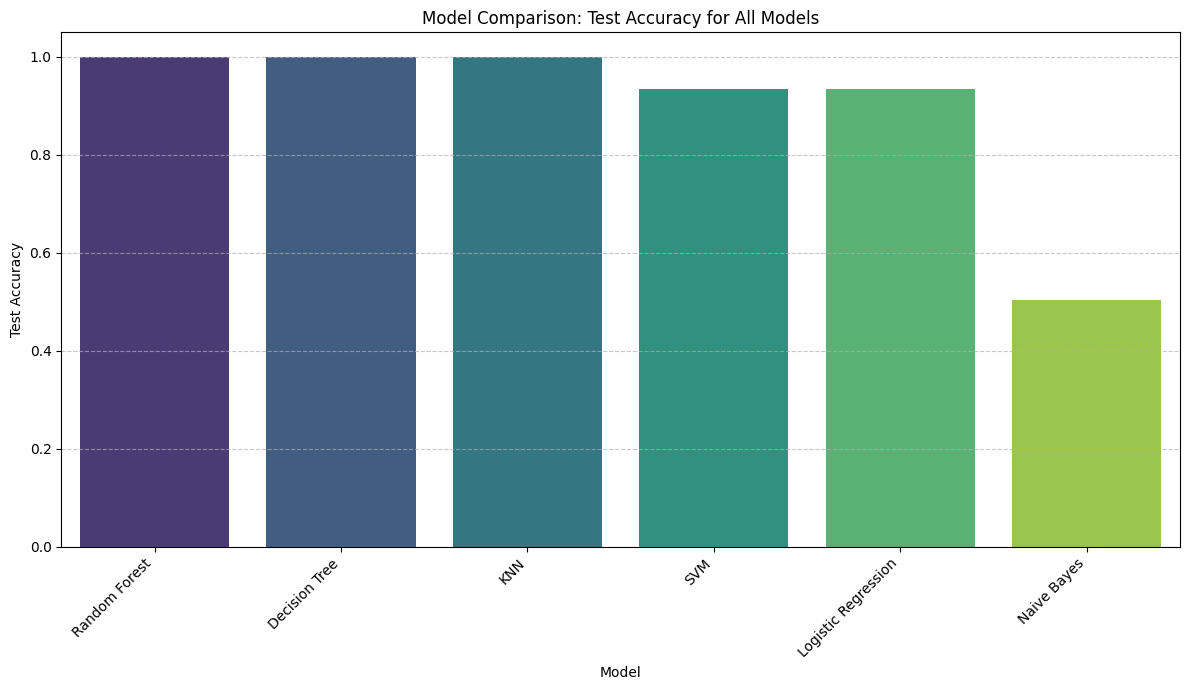

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the results by Accuracy (test accuracy) for better visualization
results_sorted_acc = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.barplot(x="Model", y="Accuracy", data=results_sorted_acc, palette="viridis")
plt.title("Model Comparison: Test Accuracy for All Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0.0, 1.05) # Ensure y-axis starts from 0 and goes slightly above 1 for clarity
plt.xticks(rotation=45, ha="right") # Rotate x-axis labels if they overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train_scaled_df)
test_pred = rf.predict(X_test_scaled_df)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9999190407535067
Test Accuracy : 0.9996279326144624


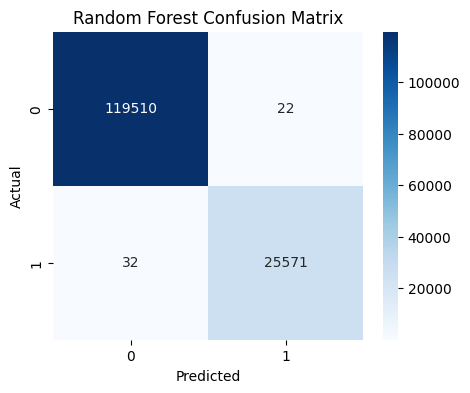

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test_scaled_df)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train_scaled_df,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.99887662 0.99890086 0.99875503 0.99870602 0.99863268]
Mean F1: 0.9987742436393676


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    119532
           1       1.00      1.00      1.00     25603

    accuracy                           1.00    145135
   macro avg       1.00      1.00      1.00    145135
weighted avg       1.00      1.00      1.00    145135



In [46]:
import joblib

model_path = os.path.join(DATA_DIR, "best_modelRandomForest.pkl")
joblib.dump(rf, model_path)

print("Best model saved:", model_path)

Best model saved: /content/drive/MyDrive/CIC-IDS- 2017/best_modelRandomForest.pkl


In [48]:
import joblib
import os

# Folder path
MODEL_DIR = os.path.join(DATA_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Save each model
joblib.dump(lr, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
joblib.dump(dt, os.path.join(MODEL_DIR, "decision_tree.pkl"))
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.pkl"))
joblib.dump(knn, os.path.join(MODEL_DIR, "knn.pkl"))
joblib.dump(nb, os.path.join(MODEL_DIR, "naive_bayes.pkl"))
joblib.dump(svm, os.path.join(MODEL_DIR, "svm.pkl"))

print("All models saved in:", MODEL_DIR)

All models saved in: /content/drive/MyDrive/CIC-IDS- 2017/models


In [51]:
import joblib
import os

MODEL_DIR = os.path.join(DATA_DIR, "models")

rf_loaded = joblib.load(os.path.join(MODEL_DIR, "random_forest.pkl"))
scaler = joblib.load(os.path.join(DATA_DIR, "scaler.pkl"))
features = joblib.load(os.path.join(DATA_DIR, "selected_features.pkl"))

print("Model, scaler, features loaded ✅")

Model, scaler, features loaded ✅


In [52]:
sample = model_df.drop("Label", axis=1).iloc[0]

print("Sample input:")
print(sample)

Sample input:
Flow Duration                        4.0
Total Fwd Packets                    2.0
Total Backward Packets               0.0
Total Length of Fwd Packets         12.0
Total Length of Bwd Packets          0.0
Flow Bytes/s                   3000000.0
Flow Packets/s                  500000.0
Packet Length Mean                   6.0
SYN Flag Count                       0.0
ACK Flag Count                       1.0
PSH Flag Count                       0.0
Average Packet Size                  9.0
Name: 0, dtype: float64


In [53]:
import numpy as np

sample_array = np.array(sample).reshape(1, -1)

# scale it
sample_scaled = scaler.transform(sample_array)

In [54]:
prediction = rf_loaded.predict(sample_scaled)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("🚨 DDoS ATTACK")
else:
    print("✅ BENIGN TRAFFIC")

Prediction: [0]
✅ BENIGN TRAFFIC


In [55]:
test_samples = model_df.drop("Label", axis=1).iloc[:5]

scaled = scaler.transform(test_samples)

preds = rf_loaded.predict(scaled)

print(preds)

[0 0 0 0 0]


In [56]:
# Get one real DDoS sample
ddos_sample = model_df[model_df["Label"] == 1].drop("Label", axis=1).iloc[0]

print("DDoS sample input:")
print(ddos_sample)

# Scale and predict
ddos_scaled = scaler.transform([ddos_sample])
ddos_prediction = rf_loaded.predict(ddos_scaled)

print("Prediction:", ddos_prediction)

if ddos_prediction[0] == 1:
    print("🚨 DDoS ATTACK")
else:
    print("✅ BENIGN TRAFFIC")

DDoS sample input:
Flow Duration                  1.293792e+06
Total Fwd Packets              3.000000e+00
Total Backward Packets         7.000000e+00
Total Length of Fwd Packets    2.600000e+01
Total Length of Bwd Packets    1.160700e+04
Flow Bytes/s                   8.991399e+03
Flow Packets/s                 7.729218e+00
Packet Length Mean             1.057545e+03
SYN Flag Count                 0.000000e+00
ACK Flag Count                 0.000000e+00
PSH Flag Count                 1.000000e+00
Average Packet Size            1.163300e+03
Name: 548801, dtype: float64
Prediction: [1]
🚨 DDoS ATTACK


In [57]:
ddos_samples = model_df[model_df["Label"] == 1].drop("Label", axis=1).iloc[:10]

ddos_scaled = scaler.transform(ddos_samples)
ddos_preds = rf_loaded.predict(ddos_scaled)

print(ddos_preds)

[1 1 1 1 1 1 1 1 1 1]


**END..............**